Experiment 1: Descriptive and Inferential Statistics
Course: CSDL8013 Applied Data Science Lab
Dataset: Online Payments Fraud Detection
Objective: To analyze statistical properties and test relationships between variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("data/online_fraud.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)


Dataset Loaded Successfully
Shape: (6362620, 11)


In [3]:
df = df.sample(n=100000, random_state=42)
print("Sampled Shape:", df.shape)


Sampled Shape: (100000, 11)


In [4]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)
df.head()


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,20866.00,351084.42,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,30370.00,18722.92,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,106589.00,258853.21,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,0.00,0.00,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3737323 to 6142173
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  object 
 2   amount          100000 non-null  float64
 3   oldbalanceOrg   100000 non-null  float64
 4   newbalanceOrig  100000 non-null  float64
 5   oldbalanceDest  100000 non-null  float64
 6   newbalanceDest  100000 non-null  float64
 7   isFraud         100000 non-null  int64  
 8   isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 7.6+ MB


In [6]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,100000.000000,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,100000.000000
mean,243.709070,1.805811e+05,8.366804e+05,8.582234e+05,1.104193e+06,1.230055e+06,0.001410,0.000010
std,142.518613,5.586699e+05,2.901104e+06,2.936799e+06,3.223011e+06,3.475326e+06,0.037524,0.003162
min,1.000000,9.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.350821e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,240.000000,7.603086e+04,1.393850e+04,0.000000e+00,1.387482e+05,2.185786e+05,0.000000,0.000000
75%,335.000000,2.091130e+05,1.070771e+05,1.464169e+05,9.605963e+05,1.126011e+06,0.000000,0.000000
max,736.000000,3.697390e+07,3.359321e+07,3.388709e+07,2.362896e+08,2.724047e+08,1.000000,1.000000


In [7]:
print("Mean:\n", df.mean(numeric_only=True))


Mean:
 step              2.437091e+02
amount            1.805811e+05
oldbalanceOrg     8.366804e+05
newbalanceOrig    8.582234e+05
oldbalanceDest    1.104193e+06
newbalanceDest    1.230055e+06
isFraud           1.410000e-03
isFlaggedFraud    1.000000e-05
dtype: float64


In [8]:
print("Median:\n", df.median(numeric_only=True))


Median:
 step                 240.000
amount             76030.865
oldbalanceOrg      13938.500
newbalanceOrig         0.000
oldbalanceDest    138748.170
newbalanceDest    218578.620
isFraud                0.000
isFlaggedFraud         0.000
dtype: float64


In [9]:
print("Mode:\n", df.mode().iloc[0])


Mode:
 step                      19
type                CASH_OUT
amount            10000000.0
oldbalanceOrg            0.0
newbalanceOrig           0.0
oldbalanceDest           0.0
newbalanceDest           0.0
isFraud                    0
isFlaggedFraud             0
Name: 0, dtype: object


In [10]:
print("Variance:\n", df.var(numeric_only=True))


Variance:
 step              2.031155e+04
amount            3.121121e+11
oldbalanceOrg     8.416406e+12
newbalanceOrig    8.624786e+12
oldbalanceDest    1.038780e+13
newbalanceDest    1.207789e+13
isFraud           1.408026e-03
isFlaggedFraud    1.000000e-05
dtype: float64


In [11]:
print("Standard Deviation:\n", df.std(numeric_only=True))


Standard Deviation:
 step              1.425186e+02
amount            5.586699e+05
oldbalanceOrg     2.901104e+06
newbalanceOrig    2.936799e+06
oldbalanceDest    3.223011e+06
newbalanceDest    3.475326e+06
isFraud           3.752367e-02
isFlaggedFraud    3.162278e-03
dtype: float64


In [12]:
print("Skewness:\n", df.skew(numeric_only=True))


Skewness:
 step                0.377314
amount             22.218818
oldbalanceOrg       5.251261
newbalanceOrig      5.182140
oldbalanceDest     16.513891
newbalanceDest     16.377039
isFraud            26.575223
isFlaggedFraud    316.227766
dtype: float64


In [13]:
print("Kurtosis:\n", df.kurt(numeric_only=True))


Kurtosis:
 step                   0.329583
amount               890.459292
oldbalanceOrg         32.878214
newbalanceOrig        32.057787
oldbalanceDest       662.578751
newbalanceDest       679.831228
isFraud              704.256542
isFlaggedFraud    100000.000000
dtype: float64


In [14]:
df['isFraud'].value_counts()


isFraud
0    99859
1      141
Name: count, dtype: int64

In [15]:
df['isFraud'].value_counts(normalize=True) * 100


isFraud
0    99.859
1     0.141
Name: proportion, dtype: float64

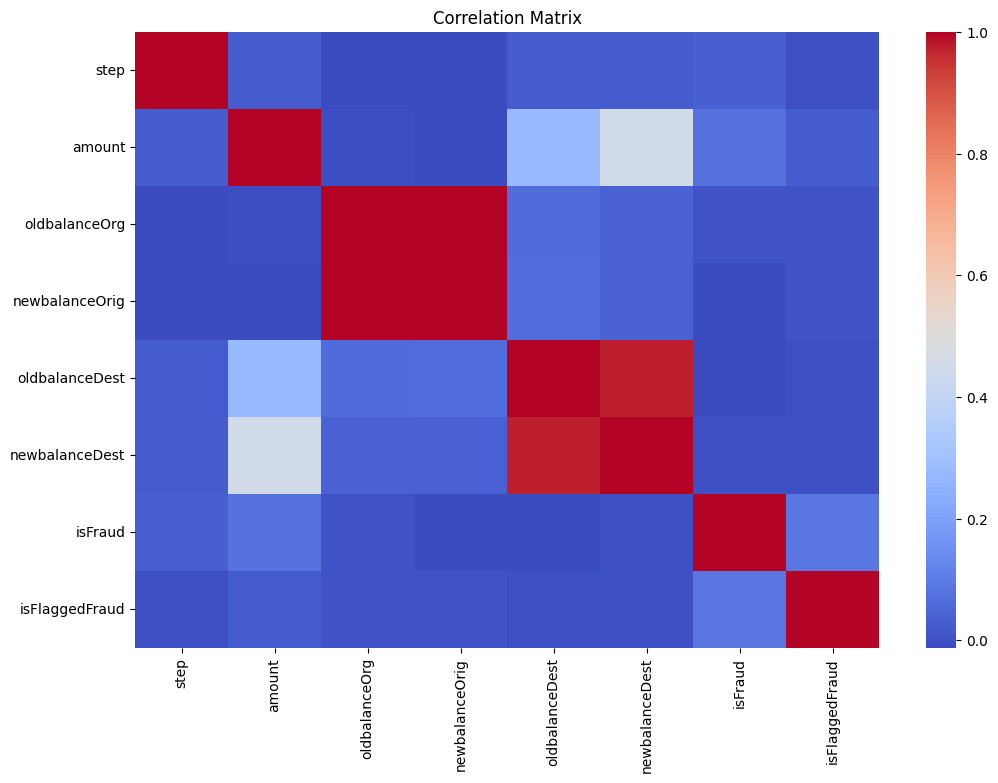

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [17]:
fraud = df[df['isFraud'] == 1]['amount']
normal = df[df['isFraud'] == 0]['amount']

t_stat, p_value = stats.ttest_ind(fraud, normal, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: 6.437343141888669
P-Value: 1.8052592956842747e-09


In [18]:
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference in transaction amount.")
else:
    print("Fail to Reject Null Hypothesis.")


Reject Null Hypothesis: Significant difference in transaction amount.


In [19]:
contingency_table = pd.crosstab(df['type'], df['isFraud'])
contingency_table


isFraud,0,1
type,,
CASH_IN,22141,0
CASH_OUT,35272,62
DEBIT,612,0
PAYMENT,33564,0
TRANSFER,8270,79


In [20]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)


Chi-Square Statistic: 466.9669855751835
P-Value: 9.322228448113239e-100


In [21]:
if p < 0.05:
    print("Significant association between transaction type and fraud.")
else:
    print("No significant association.")


Significant association between transaction type and fraud.
